# Load lipid volumes

The Lipid Brain Atlas measured **173 lipids** across the mouse brain with MALDI mass
spectrometry imaging, on coronal sections registered to the Allen reference space. IBL has
interpolated them onto the same 200 µm grid as the gene expression and MERFISH volumes, so a
lipid can be indexed, plotted and compared exactly like a gene.

For how this dataset relates to the others IBL repackages, see
[External data in the common space](../explanation/external-data-in-the-common-space.qmd).

## Loading the volumes

`lipids.load_volume()` returns three things:

| Variable | What it holds |
|---|---|
| `volume` | `(173, 58, 41, 67)` float32 log intensities — lipid by ML, DV, AP. Arbitrary units, normalised so they are comparable across sections and brains |
| `df_lipids` | One row per lipid: `lipid`, `reliability`, `sex_log_ratio`, `sex_zscore` |
| `atlas_agea` | The 200 µm atlas the volume sits on — the same object `agea.load_atlas()` returns |

The first call downloads about 110 MB. The volume is **memory-mapped**, so loading it is
quick and only the slices you touch are read from disk.

In [1]:
import matplotlib.pyplot as plt

from iblatlas.genomics import lipids

volume, df_lipids, atlas_agea = lipids.load_volume()
print(volume.shape)
df_lipids.head()

(173, 58, 41, 67)


,lipid,reliability,sex_log_ratio,sex_zscore
0,HexCer 42:2;O2,0.855576,0.054817,0.215254
1,HexCer 42:1;O2,0.843541,0.016704,0.111096
2,HexCer 40:1;O2,0.845518,0.043247,0.206737
3,PC 38:6,0.638824,0.005310,0.048747
4,PA 34:1,0.742746,-0.043730,-0.851686


## Keeping the reproducible lipids

`reliability` is the voxel-wise correlation between volumes built separately from the two
densely sampled brains. Lipids with a low reliability show stripes from one section to the
next, which are artefacts rather than anatomy, so filter on it before analysis.

Passing `min_reliability` keeps only those lipids and loads the result into memory. At 0.6,
158 of the 173 lipids remain.

In [2]:
volume, df_lipids, atlas_agea = lipids.load_volume(min_reliability=0.6)
print(len(df_lipids))

158


## Plotting a lipid

Below, the most reliable lipid is shown on a coronal slice (AP −2 mm) and a sagittal slice
(ML 1 mm), each beside the region annotation.

The volumes cover 91% of the brain. The olfactory bulb and the most anterior frontal cortex
were not sampled, so the front of the sagittal slice is empty: those voxels are NaN, not low
intensity. The two hemispheres are mirror images, because the volumes were built on one side
and reflected.

lipid          Hex2Cer 40:1;O2
reliability           0.867217
Name: 156, dtype: object


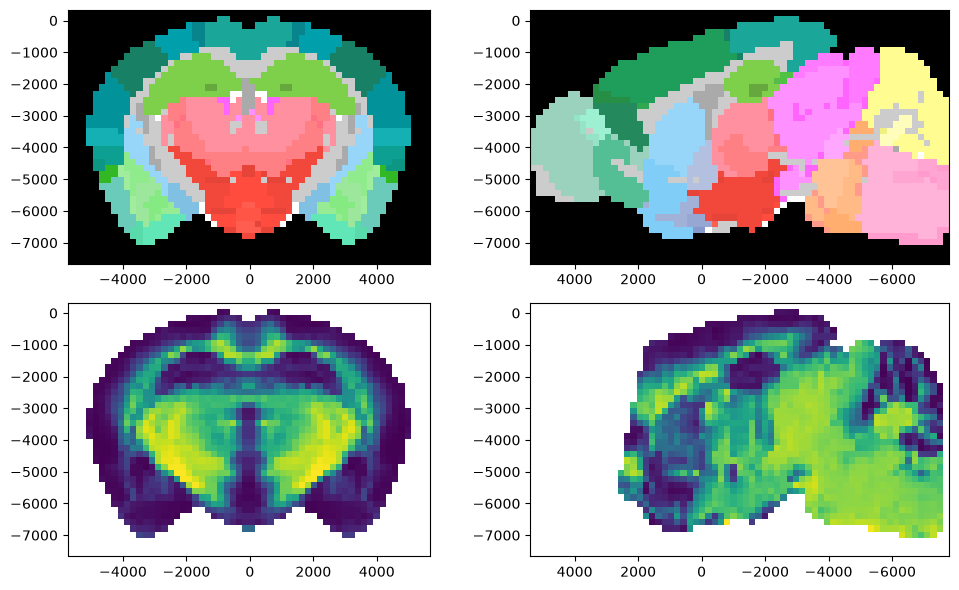

In [3]:
ilipid = df_lipids['reliability'].idxmax()
print(df_lipids.loc[ilipid, ['lipid', 'reliability']])

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
atlas_agea.plot_cslice(-0.002, ax=axs[0, 0], volume='annotation')
atlas_agea.plot_cslice(-0.002, ax=axs[1, 0], volume=volume[ilipid], cmap='viridis')
atlas_agea.plot_sslice(0.001, ax=axs[0, 1], volume='annotation')
atlas_agea.plot_sslice(0.001, ax=axs[1, 1], volume=volume[ilipid], cmap='viridis')
fig.tight_layout()

## Citing this data

::: {.callout-note}
## Credit the Lipid Brain Atlas

The lipid volumes are a derivative of the Lipid Brain Atlas data, distributed under
CC-BY 4.0. Any use must credit the original work:

- Fusar Bassini L. et al., "The lipidomic architecture of the mouse brain", *Nature* (2026),
  [doi:10.1038/s41586-026-11050-0](https://doi.org/10.1038/s41586-026-11050-0)
- Source data: [doi:10.5281/zenodo.15379565](https://doi.org/10.5281/zenodo.15379565)
:::